<a href="https://colab.research.google.com/github/AlisaLeibova/ML-study/blob/main/%D0%9F%D0%BE%D0%BB%D0%BE%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

ROC AUC на наборі Train: 90.21%


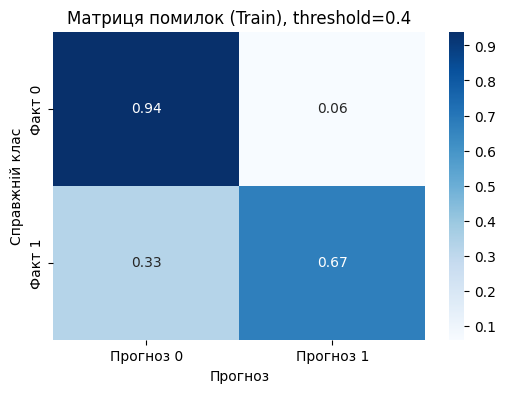

ROC AUC на наборі Validation: 88.43%


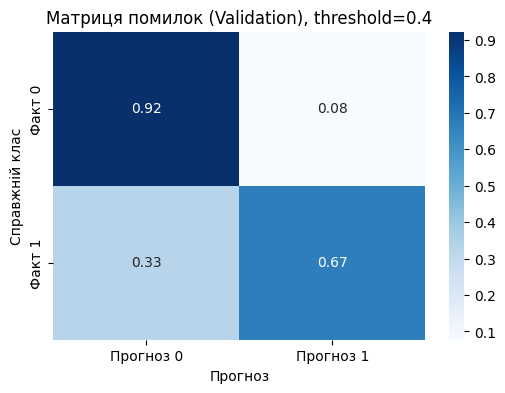

Модель збережено у файл: log_reg.joblib


In [ ]:
# =========================
# 1. Імпорт бібліотек
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix


# =========================
# 2. Завантаження даних
# =========================
raw_df = pd.read_csv('train.csv', index_col=0)


# =========================
# 3. Розбиття на train/validation
# =========================
train_df, val_df = train_test_split(
    raw_df,
    test_size=0.2,
    random_state=42,
    stratify=raw_df['Exited']
)


# =========================
# 4. Формування вхідних ознак і цільової змінної
# =========================
input_cols = list(train_df.columns)[1:-1]
target_col = 'Exited'

train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

val_inputs = val_df[input_cols]
val_targets = val_df[target_col]


# =========================
# 5. Визначення числових і категоріальних колонок
# =========================
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()


# =========================
# 6. Пайплайн для числових ознак
#    - заповнення пропусків середнім
#    - масштабування
# =========================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])


# =========================
# 7. Пайплайн для категоріальних ознак
#    - заповнення пропусків
#    - one-hot кодування
# =========================
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])


# =========================
# 8. Об'єднання препроцесингу
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


# =========================
# 9. Повний пайплайн:
#    спочатку препроцесинг,
#    потім логістична регресія
# =========================
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])


# =========================
# 10. Навчання моделі
# =========================
model_pipeline.fit(train_inputs, train_targets)


# =========================
# 11. Функція для прогнозу, ROC AUC
#     і confusion matrix у долях
# =========================
def predict_and_plot(model_pipeline, inputs, targets, name='', threshold=0.4):
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    preds = (probs >= threshold).astype(int)

    roc_auc = roc_auc_score(targets, probs) * 100
    print(f"ROC AUC на наборі {name}: {roc_auc:.2f}%")

    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        confusion_matrix_,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=['Прогноз 0', 'Прогноз 1'],
        yticklabels=['Факт 0', 'Факт 1']
    )
    plt.xlabel('Прогноз')
    plt.ylabel('Справжній клас')
    plt.title(f'Матриця помилок ({name}), threshold={threshold}')
    plt.show()

    return preds


# =========================
# 12. Оцінка моделі на train
# =========================
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train', threshold=0.4)


# =========================
# 13. Оцінка моделі на validation
# =========================
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation', threshold=0.4)

# =========================
# 14. Якщо є окремий test-набір:
#     приклад оцінки на test
# =========================
# test_df = pd.read_csv('test.csv', index_col=0)
# test_inputs = test_df[input_cols]
# test_targets = test_df[target_col]
# test_preds = predict_and_plot(model_pipeline, test_inputs, test_targets, 'Test')


# =========================
# 15. Збереження моделі для подальшого використання
# =========================
objects_to_save = {
    'model_pipeline': model_pipeline,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols
}

joblib.dump(objects_to_save, 'log_reg.joblib')
print("Модель збережено у файл: log_reg.joblib")

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

ROC AUC на наборі Train (Poly): 92.68%


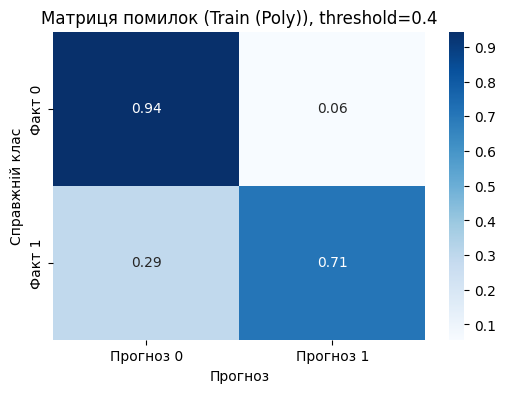

ROC AUC на наборі Validation (Poly): 91.35%


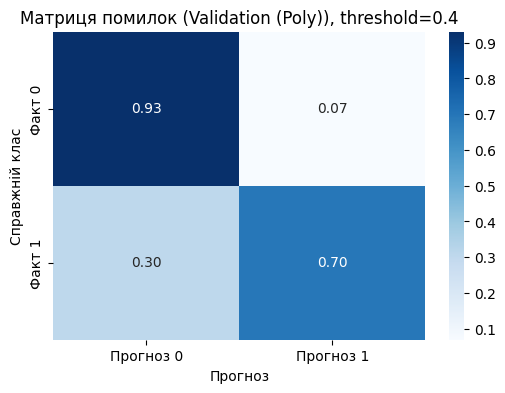

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

numeric_transformer_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', MinMaxScaler())
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

model_pipeline_poly.fit(train_inputs, train_targets)

train_preds_poly = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Train (Poly)')
val_preds_poly = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation (Poly)')

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

ROC AUC на наборі Train (Poly 4): 94.40%


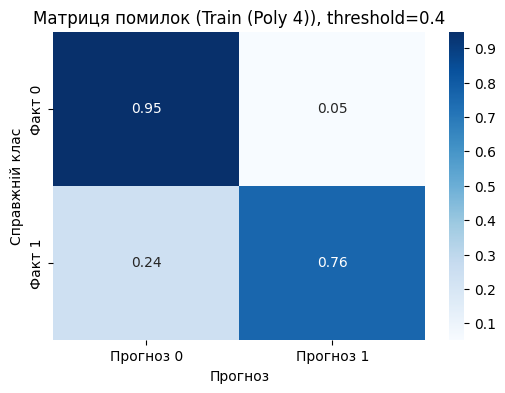

ROC AUC на наборі Validation (Poly 4): 93.12%


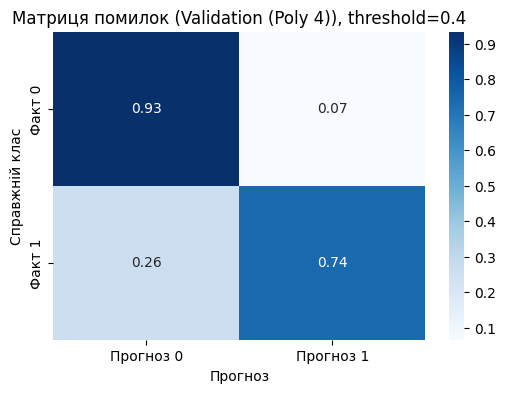

,id,Exited
0,15000,0.0
1,15001,0.0
2,15002,0.0
3,15003,1.0
4,15004,0.0


(10000, 2)


In [ ]:
# =========================
# 1. Числовая предобработка
#    Полиномиальные признаки 4-й степени
# =========================
numeric_transformer_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', MinMaxScaler())
])

# =========================
# 2. Новый препроцессор
# =========================
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# =========================
# 3. Новый пайплайн
# =========================
model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# =========================
# 4. Обучение
# =========================
model_pipeline_poly.fit(train_inputs, train_targets)

# =========================
# 5. Оценка на train и validation
# =========================
train_preds_poly = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Train (Poly 4)')
val_preds_poly = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation (Poly 4)')

# =========================
# 6. Предсказание на test
# =========================
test_df = pd.read_csv('test.csv', index_col=0)
test_inputs = test_df[input_cols]
test_preds = model_pipeline_poly.predict(test_inputs)

# =========================
# 7. Формирование файла для Kaggle
# =========================
submission = pd.DataFrame({
    'id': test_df.index,
    'Exited': test_preds
})

# =========================
# 8. Проверки
# =========================
sample_submission = pd.read_csv('sample_submission.csv')

assert submission.shape[0] == sample_submission.shape[0]
assert submission.columns.tolist() == sample_submission.columns.tolist()
assert submission['Exited'].between(0, 1).all()

# =========================
# 9. Сохранение
# =========================
submission.to_csv('submission_logreg.csv', index=False)

display(submission.head())
print(submission.shape)

Висновки: Модель с полиміальними ознаками в 4 ступені дає найкращий ROC та показник вгадування класу 1 TPR(що є ключевим в нашій задачі). ROC на train i на validation не сильно відрізняється один від одного. Це означає, що модель стала більш гнучкою, краще вловлює нелінійні залежності та добре узагальнює дані. Ознак сильного overfit або underfit не спостерігається
Я буду використовувати цю модель для сабмішену в Kaggle

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [47]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Загружаем данные
regression_df = pd.read_csv('regression_data.csv')

# Указываем целевой столбец
target_col = 'target'   # если у тебя другое имя, замени здесь

# Делим на признаки и цель
X = regression_df.drop(columns=[target_col])
y = regression_df[target_col]

# Оставляем числовые признаки
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
X = X[numeric_cols]

# Делим на train и validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Создаём pipeline: масштабирование -> полиномиальные признаки степени 5 -> линейная регрессия
model = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('regressor', LinearRegression())
])

# Обучаем модель
model.fit(X_train, y_train)

# Предсказания
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

# Метрики
train_r2 = r2_score(y_train, train_preds)
val_r2 = r2_score(y_val, val_preds)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))

train_mae = mean_absolute_error(y_train, train_preds)
val_mae = mean_absolute_error(y_val, val_preds)

print("Train metrics:")
print("R2   =", train_r2)
print("RMSE =", train_rmse)
print("MAE  =", train_mae)

print("\nValidation metrics:")
print("R2   =", val_r2)
print("RMSE =", val_rmse)
print("MAE  =", val_mae)

# 11. Простой вывод о качестве модели
print("\nВисновок:")
if train_r2 > 0.9 and val_r2 > 0.9 and abs(train_r2 - val_r2) < 0.05:
    print("Модель хороша і добре генералізує.")
elif train_r2 > val_r2 and abs(train_r2 - val_r2) > 0.1:
    print("Є ознаки перенавчання: модель добре працює на train, але гірше на validation.")
else:
    print("Модель працює помірно; якість або генералізація потребують додаткової перевірки.")

Train metrics:
R2   = 1.0
RMSE = 3.270327237584462e-13
MAE  = 2.1053493360760662e-13

Validation metrics:
R2   = 0.4559269150836036
RMSE = 35.62805277364308
MAE  = 23.00106511993734

Висновок:
Є ознаки перенавчання: модель добре працює на train, але гірше на validation.


**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?